<a href="https://colab.research.google.com/github/amoukrim/Python/blob/main/Week2/ExerciseXP/ExerciceXP_w2d5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Mini-Project: Data Analysis for Marketing Strategy

In this mini-project, we will perform data analysis to devise a marketing strategy based on various aspects like area analysis, customer analysis, product category analysis, and sales and profit time series.


## 🗃️ le fichier de données

The US "US Superstore data.xls" contains the following attributes:

- Row ID: Unique ID for each row.
- Order ID: Unique Order ID for each Customer.
- Order Date: Order Date of the product.
- Ship Date: Shipping Date of the Product.
- Ship Mode: Shipping Mode specified by the Customer.
- Customer ID: Unique ID to identify each Customer.
- Customer Name: Name of the Customer.
- Segment: The segment where the Customer belongs.
- Country: Country of residence of the Customer.
- City: City of residence of the Customer.
- State: State of residence of the Customer.
- Postal Code: Postal Code of every Customer.
- Region: Region where the Customer belongs.
- Product ID: Unique ID of the Product.
- Category: Category of the product ordered.
- Sub-Category: Sub-Category of the product ordered.
- Product Name: Name of the Product.
- Sales: Sales of the Product.
- Quantity: Quantity of the Product.
- Discount: Discount provided.
- Profit: Profit/Loss incurred.


In [1]:
# import des librairies nécessaires
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#lecture du fichier
file_path = "/content/US Superstore data.xls"
df = pd.read_excel(file_path, engine="xlrd")

# Conversion des dates
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#2 États avec le plus de ventes

/tmp/ipython-input-2-272014325.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_sales.values, y=state_sales.index, palette="viridis")


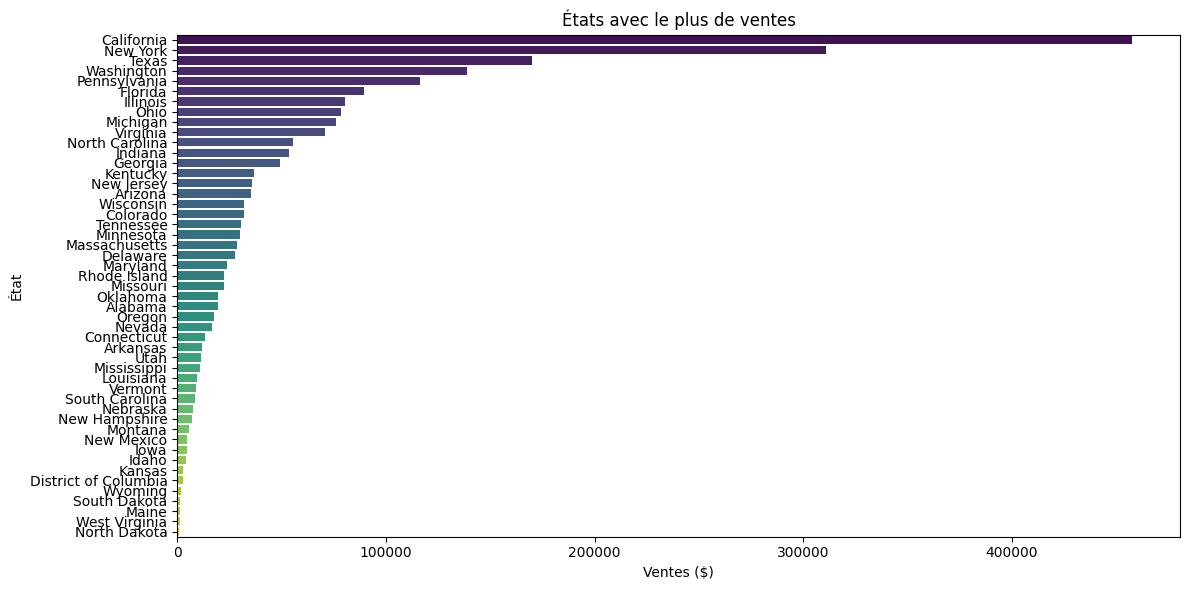

In [2]:
# Total des ventes par état
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=state_sales.values, y=state_sales.index, palette="viridis")
plt.title("États avec le plus de ventes")
plt.xlabel("Ventes ($)")
plt.ylabel("État")
plt.tight_layout()
plt.show()


# 3  Comparaison New York vs California

In [3]:

ny = df[df["State"] == "New York"]
ca = df[df["State"] == "California"]

print("New York - Ventes totales :", round(ny["Sales"].sum(), 2))
print("New York - Profit total :", round(ny["Profit"].sum(), 2))
print("California - Ventes totales :", round(ca["Sales"].sum(), 2))
print("California - Profit total :", round(ca["Profit"].sum(), 2))


New York - Ventes totales : 310876.27
New York - Profit total : 74038.55
California - Ventes totales : 457687.63
California - Profit total : 76381.39


# 4 Meilleur client à New York

In [4]:
ny_customer = ny.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(1)
ny_customer


,Sales
Customer Name,
Tom Ashbrook,13723.498


#5 Rentabilité par État

/tmp/ipython-input-5-901508714.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_profit.values, y=state_profit.index, palette="coolwarm")


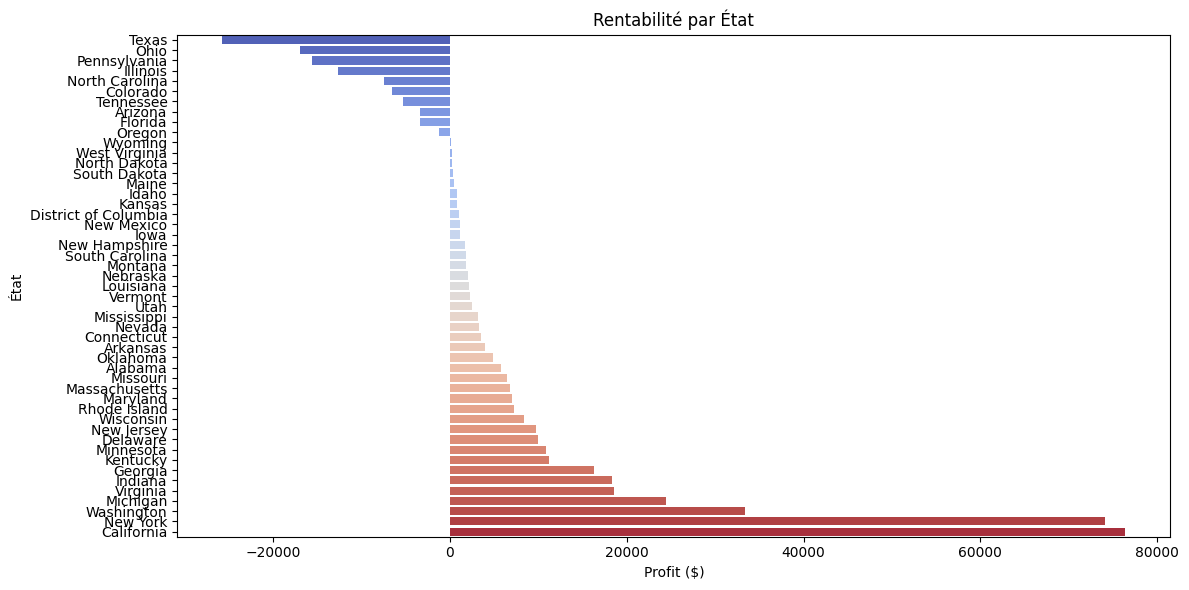

In [5]:
state_profit = df.groupby("State")["Profit"].sum().sort_values()

plt.figure(figsize=(12, 6))
sns.barplot(x=state_profit.values, y=state_profit.index, palette="coolwarm")
plt.title("Rentabilité par État")
plt.xlabel("Profit ($)")
plt.ylabel("État")
plt.tight_layout()
plt.show()


# 6 Principe de Pareto sur le Profit par client

In [6]:
profit_by_customer = df.groupby("Customer ID")["Profit"].sum().sort_values(ascending=False)
cumulative_profit = profit_by_customer.cumsum()
total_profit = profit_by_customer.sum()
cutoff = cumulative_profit[cumulative_profit <= 0.8 * total_profit]

print("Nombre total de clients :", len(profit_by_customer))
print("Clients représentant 80% du profit :", len(cutoff), "→", round(100 * len(cutoff)/len(profit_by_customer), 2), "%")


Nombre total de clients : 793
Clients représentant 80% du profit : 152 → 19.17 %


# 7  Top 20 villes par ventes et profits

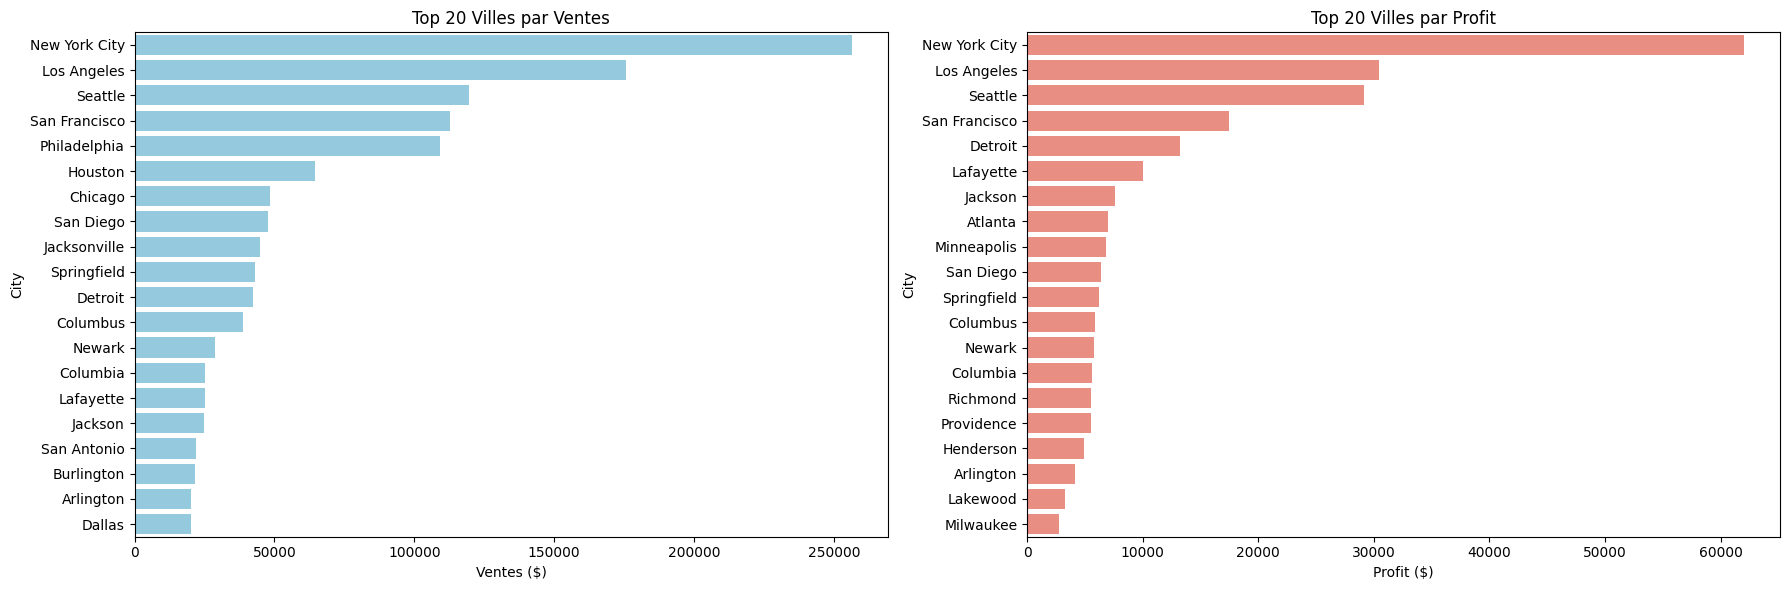

In [7]:
top_sales_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(20)
top_profit_cities = df.groupby("City")["Profit"].sum().sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(x=top_sales_cities.values, y=top_sales_cities.index, ax=axes[0], color='skyblue')
axes[0].set_title("Top 20 Villes par Ventes")
axes[0].set_xlabel("Ventes ($)")

sns.barplot(x=top_profit_cities.values, y=top_profit_cities.index, ax=axes[1], color='salmon')
axes[1].set_title("Top 20 Villes par Profit")
axes[1].set_xlabel("Profit ($)")

plt.tight_layout()
plt.show()


# 8 Top 20 clients par ventes

/tmp/ipython-input-8-653200872.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers_sales.values, y=top_customers_sales.index, palette="mako")


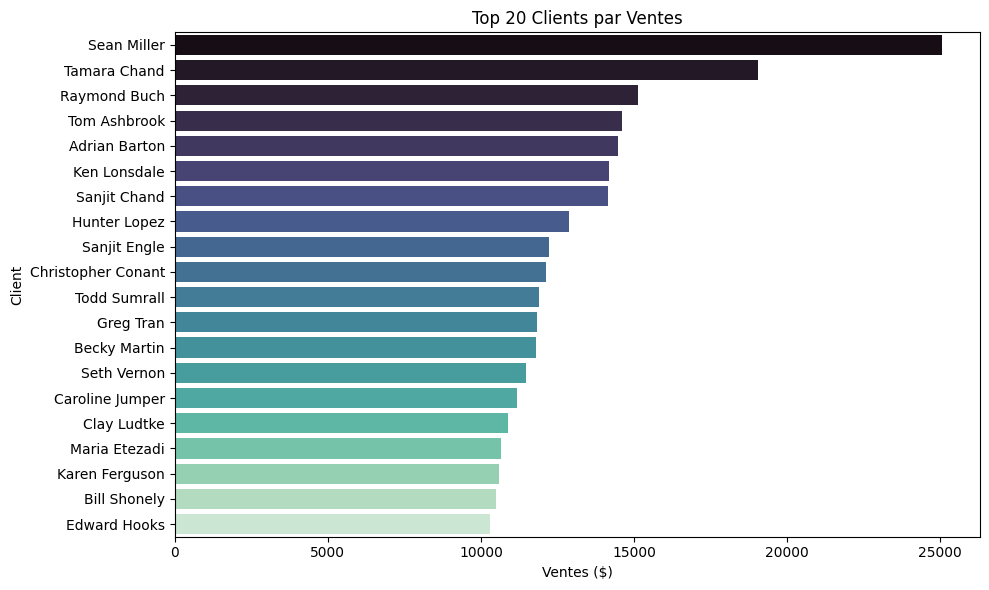

In [8]:
top_customers_sales = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers_sales.values, y=top_customers_sales.index, palette="mako")
plt.title("Top 20 Clients par Ventes")
plt.xlabel("Ventes ($)")
plt.ylabel("Client")
plt.tight_layout()
plt.show()


# 9 Courbe cumulative de ventes clients (Pareto)

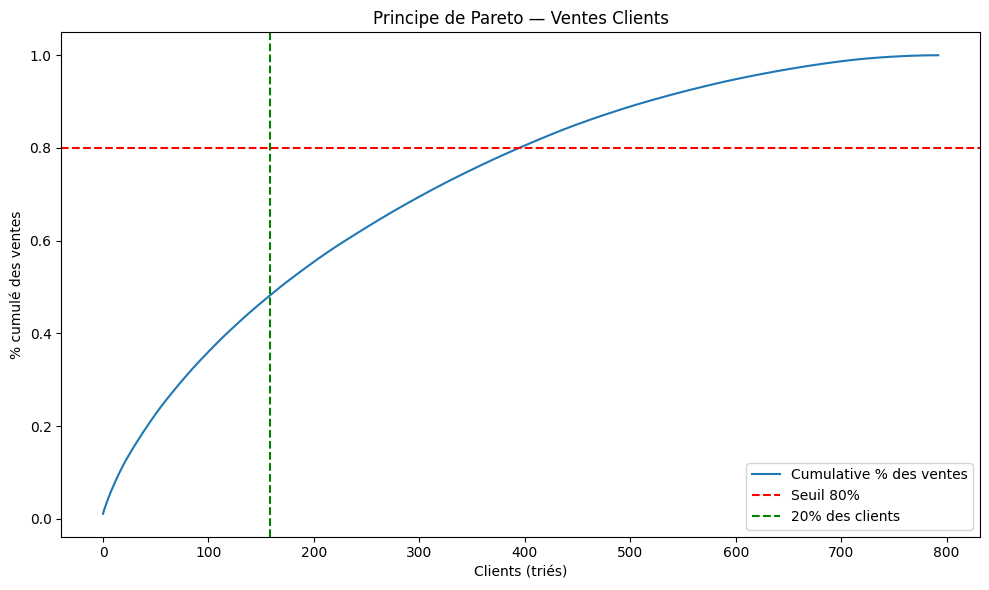

In [9]:
sales_by_customer = df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False)
cumulative_sales = sales_by_customer.cumsum()
total_sales = sales_by_customer.sum()

plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(sales_by_customer)), cumulative_sales / total_sales, label="Cumulative % des ventes")
plt.axhline(0.8, color='red', linestyle='--', label="Seuil 80%")
plt.axvline(int(len(sales_by_customer)*0.2), color='green', linestyle='--', label="20% des clients")
plt.title("Principe de Pareto — Ventes Clients")
plt.xlabel("Clients (triés)")
plt.ylabel("% cumulé des ventes")
plt.legend()
plt.tight_layout()
plt.show()


# 10 Analyse des catégories de produits

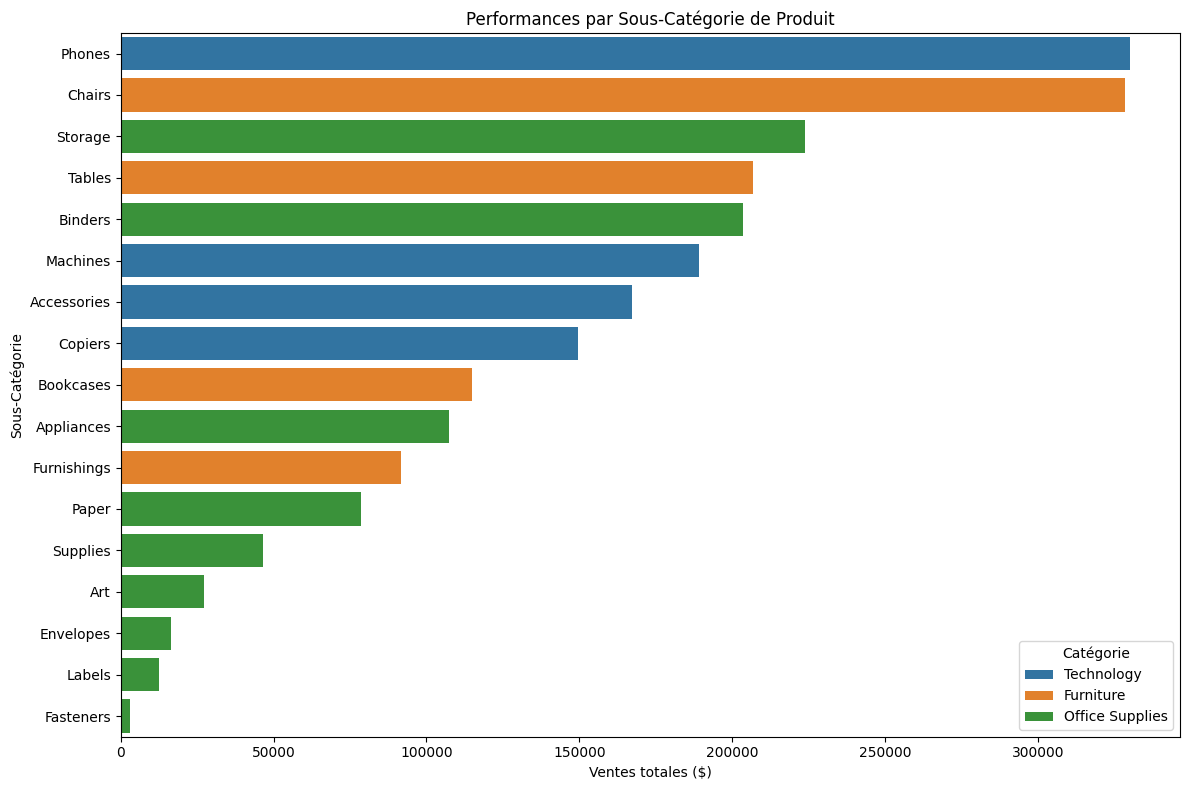

In [10]:
cat_perf = df.groupby(["Category", "Sub-Category"])     .agg(Total_Sales=("Sales", "sum"), Total_Profit=("Profit", "sum"))     .sort_values(by="Total_Sales", ascending=False).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(x="Total_Sales", y="Sub-Category", hue="Category", data=cat_perf, dodge=False)
plt.title("Performances par Sous‑Catégorie de Produit")
plt.xlabel("Ventes totales ($)")
plt.ylabel("Sous‑Catégorie")
plt.legend(title="Catégorie")
plt.tight_layout()
plt.show()


# 11 Analyse des tendances dans le temps

/tmp/ipython-input-11-4003776238.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  time_series = df.set_index("Order Date").resample("M")     .agg(Monthly_Sales=("Sales", "sum"), Monthly_Profit=("Profit", "sum"))


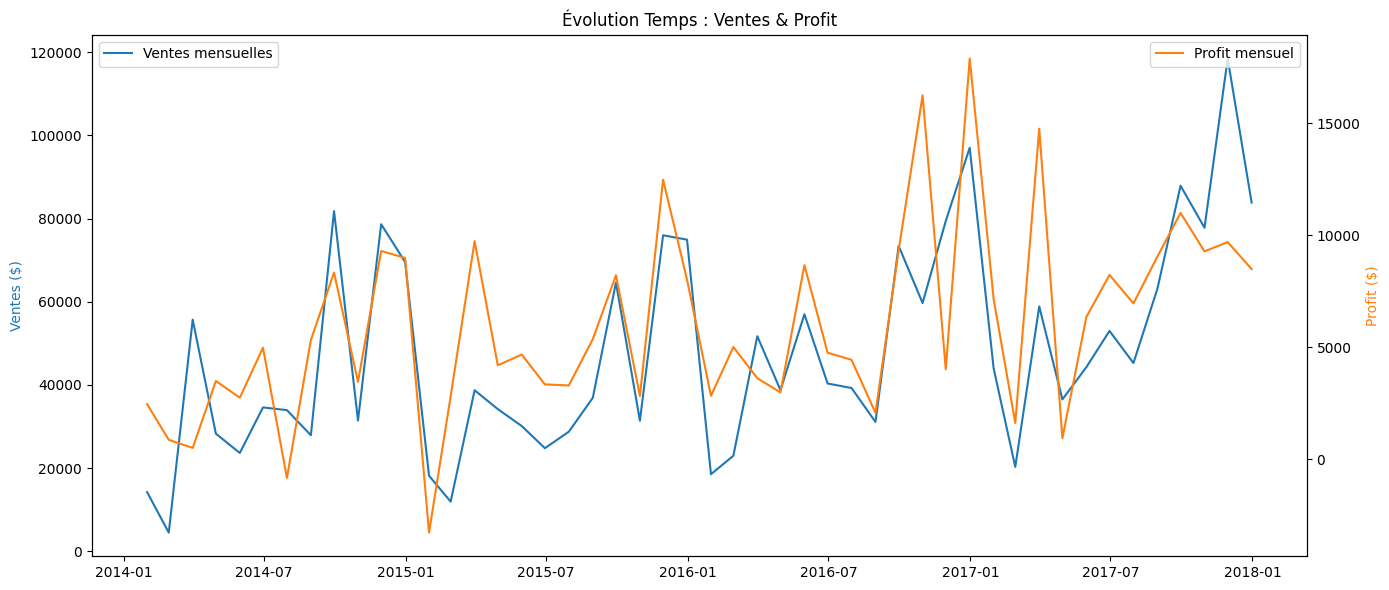

In [11]:
time_series = df.set_index("Order Date").resample("M")     .agg(Monthly_Sales=("Sales", "sum"), Monthly_Profit=("Profit", "sum"))

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(time_series.index, time_series.Monthly_Sales, label="Ventes mensuelles", color="tab:blue")
ax1.set_ylabel("Ventes ($)", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(time_series.index, time_series.Monthly_Profit, label="Profit mensuel", color="tab:orange")
ax2.set_ylabel("Profit ($)", color="tab:orange")
plt.title("Évolution Temps : Ventes & Profit")
ax1.legend(loc="upper left"); ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()


#12 Recommandations & décisions
 L’analyse du Superstore américain nous donne de précieuses pistes pour orienter intelligemment votre stratégie marketing. Voici ce qu’il en ressort :

 Les États à mettre en priorité
# Les plus prometteurs : là où ventes et profits explosent
Certaines régions se distinguent clairement : elles vendent beaucoup et génèrent du profit. En d’autres mots, ce sont les endroits où vos efforts porteront vraiment leurs fruits.

Californie : championne incontestée, avec le plus haut chiffre d’affaires et la meilleure rentabilité.

New York : un marché presque aussi fort, très bon équilibre entre ventes et profits.

Washington : discret mais très efficace, bon élève sur tous les plans.

Ce qu’il faut faire : renforcer la présence dans ces États ! Campagnes ciblées, promotions, programmes de fidélité… car ce sera rentable.
Les états avec un profit bas ou négatif sont
Texas, Ohio et Pennsylvania, il faut les surveiller de près.

